In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

def max_peaks_separation(etotal_kwh_h: pd.Series, top_n=7,
                         sleep_hours=(1,2,3,4)) -> pd.Series:
    """
    Returns a boolean Series dhw_event_hour where True means hour is tagged as 'SH+DHW'
    using Leiria 'maximum peaks': top_n hours/day (excluding sleep hours), with sleep hours forced SH-only.
    Ref: 'seven-highest' + sleep 1:00–4:00 h :contentReference[oaicite:3]{index=3}
    """
    s = etotal_kwh_h.copy().dropna()
    dhw = pd.Series(False, index=s.index)

    for day, grp in s.groupby(s.index.normalize()):
        # force sleep hours as SH-only
        grp_non_sleep = grp[~grp.index.hour.isin(sleep_hours)]
        if len(grp_non_sleep) == 0:
            continue
        # pick top_n within non-sleep hours
        picks = grp_non_sleep.nlargest(min(top_n, len(grp_non_sleep))).index
        dhw.loc[picks] = True

    return dhw.reindex(etotal_kwh_h.index).fillna(False)


def kalman_smooth_impute(sh_with_nans: pd.Series) -> pd.Series:
    """
    Structural time series "local level" Kalman smoother (analog to StructTS smoothed in the paper).
    """
    y = sh_with_nans.astype(float)

    # statsmodels can handle missing values directly in the state-space setup
    mod = sm.tsa.UnobservedComponents(y, level="local level")
    res = mod.fit(disp=False)

    # smoothed signal is the model-implied estimate of y_t
    y_smoothed = pd.Series(res.fittedvalues, index=y.index, name="SH_kalman")
    return y_smoothed


def fit_svr_sh(etotal, tout, rad) -> Pipeline:
    """
    SVR features as in Leiria: Tout[i-1,i-2], Rad[i-1], ETotal[i-1,i+1]
    with RBF kernel, C=7, gamma=0.01 :contentReference[oaicite:4]{index=4}
    """
    X = pd.DataFrame({
        "Tout_1": tout.shift(1),
        "Tout_2": tout.shift(2),
        "Rad_1": rad.shift(1),
        "ETotal_1": etotal.shift(1),
        "ETotal_p1": etotal.shift(-1),
    })

    # We'll train only on rows where target exists and features exist
    return X


def leiria_dhw_disaggregate(df_hourly: pd.DataFrame,
                           col_etotal="ETotal_kWh_h",
                           col_tout="External_Air_Temperature",
                           col_rad="Global_Horizontal_Irradiance",
                           top_n=7,
                           gap_hours_kalman=2):
    """
    Full best method:
      1) Separate DHW-event hours via maximum-peaks.
      2) Set those hours as NaN in SH series.
      3) Estimate SH at NaNs using:
           - Kalman smoother for gaps <= 2 hours,
           - SVR for longer gaps.
      4) DHW = ETotal - SH_est
      5) Bound SH_est to [0, ETotal] :contentReference[oaicite:5]{index=5}
    """
    df = df_hourly.copy().sort_index()

    etotal = df[col_etotal].astype(float)
    tout = df[col_tout].astype(float)
    rad = df[col_rad].astype(float)

    # ---- 1) separation ----
    dhw_event = max_peaks_separation(etotal, top_n=top_n)

    # SH-only observations
    sh_obs = etotal.mask(dhw_event, np.nan)

    # ---- 2) Kalman smoother on the whole series ----
    sh_kal = kalman_smooth_impute(sh_obs)

    # Identify missing runs (DHW-event hours)
    is_missing = sh_obs.isna()
    run_id = (is_missing != is_missing.shift(1)).cumsum()
    run_len = is_missing.groupby(run_id).transform("sum")

    use_kalman = is_missing & (run_len <= gap_hours_kalman)

    # Start with observed SH where available; fill small gaps with kalman
    sh_est = sh_obs.copy()
    sh_est.loc[use_kalman] = sh_kal.loc[use_kalman]

    # ---- 3) SVR for larger gaps ----
    # Build feature matrix
    X = pd.DataFrame({
        "Tout_1": tout.shift(1),
        "Tout_2": tout.shift(2),
        "Rad_1": rad.shift(1),
        "ETotal_1": etotal.shift(1),
        "ETotal_p1": etotal.shift(-1),
    }, index=df.index)

    # Train on SH-known points (not missing) with complete features
    train_mask = sh_obs.notna() & X.notna().all(axis=1)
    X_train = X.loc[train_mask]
    y_train = sh_obs.loc[train_mask]

    svr = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=7, gamma=0.01))
    ])
    svr.fit(X_train, y_train)

    # Predict only where still missing and features exist
    pred_mask = sh_est.isna() & X.notna().all(axis=1)
    sh_est.loc[pred_mask] = svr.predict(X.loc[pred_mask])

    # ---- 4) bounds (paper rule) ----
    # if SH_est < 0 => 0 ; if SH_est > ETotal => ETotal :contentReference[oaicite:6]{index=6}
    sh_est = sh_est.clip(lower=0)
    sh_est = pd.concat([sh_est, etotal], axis=1).min(axis=1)

    dhw_est = (etotal - sh_est).clip(lower=0)

    out = df.copy()
    out["DHW_event_hour"] = dhw_event.astype(int)
    out["SH_obs_kWh_h"] = sh_obs
    out["SH_est_kWh_h"] = sh_est
    out["DHW_est_kWh_h"] = dhw_est
    return out


In [2]:
#df_data = pd.read_parquet("training_data/initial_dataset.parquet")
#df_train_detached = pd.read_parquet(
#    "training_data/data_detached_with_weather.parquet")
df_train_detached = pd.read_parquet(
    "detached_home_data.parquet")
#type(df_data)
#type(df_train_detached)
#df_train_detached

In [3]:
df_train_detached_half_hour = pd.read_parquet(
    "training_data/data_detached_with_weather.parquet")

In [68]:
unique_ids = df_train_detached_half_hour["Property_ID"].unique() 
#df_train_detached["Property_ID"].unique()
id_use = unique_ids[0]
df_house = pd.read_csv('training_data/home_characteristics.csv')

In [69]:
df_house

,Bedrooms,Building_exp,Comment,Cook_Replaced,Cooling,Cooling_Rooms,Cost_Cooling,Cost_DP,Cost_Door,Cost_Emitters,...,TS_PCM_Size,TS_Type,TS_Water_Size,Technology_exp,Tenure,Tenure_Length,Total_Floor_Area,Upgrade_exp,Wall_Type,usmart_id
0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,NaN,151.0,NaN,Cavity_No_insulation,V4ZOh4sBvqZCst4RZtPN
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,28.0,135.0,NaN,Cavity_Insulated,dIZOh4sBvqZCst4RZtPN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,15.0,NaN,NaN,NaN,s4ZOh4sBvqZCst4RZtPN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,12.0,NaN,NaN,NaN,toZOh4sBvqZCst4RZtPN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,0.9,NaN,NaN,NaN,yYZOh4sBvqZCst4RZtPN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,24.0,NaN,NaN,NaN,watOh4sB1ZLwQCcBc3P5
3202,NaN,"Ground floor has already been upgraded, likely...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,6.0,NaN,We installed an efficient gas system when we l...,NaN,0atOh4sB1ZLwQCcBc3P5
3203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Owner-Occupied,2.0,NaN,NaN,NaN,1qtOh4sB1ZLwQCcBc3P5
3204,2.0,The house is a project. The electrics look an...,NaN,0.0,No,0.0,0.0,0.0,0.0,0.00,...,NaN,Water_New,210.0,Ive long worked in the industry and never been...,Owner-Occupied,NaN,82.2,When I moved in I knew I had to do something a...,Cavity_Insulated,9atOh4sB1ZLwQCcBc3P5


In [70]:

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual", "HP_Size_kW", "No_Adults",
    "No_Child"
]

# calculate min capacity in home 
cp_air = 1.005  #kJ/kgK
rho_air = 1.225  # kg/m^3
kj_to_kWh = 1 / 3600
df_house["Volume"] = df_house["Total_Floor_Area"] * df_house["Floor_Height"]
df_house["Min Capacity"] = df_house["Volume"] * cp_air * rho_air * kj_to_kWh
df_house["Occupancy"] = df_house["No_Child"] + df_house["No_Adults"]
df_home_values = df_house[df_house["Property_ID"].isin(unique_ids)] 
#df_house[df_house["Property_ID"].isin(unique_ids)]

summary = df_home_values[["Property_ID", "Min Capacity"]].drop_duplicates()
print(summary)

home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")

trained_params = pd.DataFrame(index=["Floor Area", "No_Storeys", "Wall_Type",
                                     "C", "R_a", "w_s", "w_w", "w",
                                     "Q_hat", "Q_sc", "rmse_dTi",
                                     "rmse_q_hp"])

df_home_single = df_home_values[df_home_values["Property_ID"] == id_use]

     Property_ID  Min Capacity
76       EOH3196      0.086941
318      EOH0413      0.094570
585      EOH2329      0.099645
736      EOH1637      0.088733
1149     EOH3154      0.116411
1156     EOH2675      0.124696
1569     EOH1485      0.115696
1692     EOH0546      0.088239
2066     EOH0279      0.138493
2381     EOH1703      0.074688


In [80]:
df_home_single

,Bedrooms,Building_exp,Comment,Cook_Replaced,Cooling,Cooling_Rooms,Cost_Cooling,Cost_DP,Cost_Door,Cost_Emitters,...,Technology_exp,Tenure,Tenure_Length,Total_Floor_Area,Upgrade_exp,Wall_Type,usmart_id,Volume,Min Capacity,Occupancy
2066,4.0,NaN,NaN,0.0,No,0.0,NaN,NaN,NaN,4329.22,...,NaN,Owner-Occupied,6.0,172.33,NaN,Cavity_Insulated,T69Oh4sBh3U2-eRMaumZ,404.9755,0.138493,2.0


In [71]:
df_train_detached

Timestamp  \
Property_ID Timestamp                                  
EOH0005     2021-05-21 12:22:00  2021-05-21 12:22:00   
            2021-05-21 12:24:00  2021-05-21 12:24:00   
            2021-05-21 12:26:00  2021-05-21 12:26:00   
            2021-05-21 12:28:00  2021-05-21 12:28:00   
            2021-05-21 12:30:00  2021-05-21 12:30:00   
...                                              ...   
EOH1669     2023-09-28 23:50:00  2023-09-28 23:50:00   
            2023-09-28 23:52:00  2023-09-28 23:52:00   
            2023-09-28 23:54:00  2023-09-28 23:54:00   
            2023-09-28 23:56:00  2023-09-28 23:56:00   
            2023-09-28 23:58:00  2023-09-28 23:58:00   

                                 Circulation_Pump_Energy_Consumed  \
Property_ID Timestamp                                               
EOH0005     2021-05-21 12:22:00                             0.000   
            2021-05-21 12:24:00                             0.001   
            2021-05-21 12:26:00                             0.002   
            2021-05-21 12:28:00                             0.003   
            2021-05-21 12:30:00                             0.005   
...                                                           ...   
EOH1669     2023-09-28 23:50:00                             0.000   
            2023-09-28 23:52:00                             0.000   
            2023-09-28 23:54:00                             0.000   
            2023-09-28 23:56:00                             0.000   
            2023-09-28 23:58:00                             0.000   

                                 External_Air_Temperature  \
Property_ID Timestamp                                       
EOH0005     2021-05-21 12:22:00                       NaN   
            2021-05-21 12:24:00                      8.68   
            2021-05-21 12:26:00                      8.67   
            2021-05-21 12:28:00                      8.66   
            2021-05-21 12:30:00                      8.65   
...                                                   ...   
EOH1669     2023-09-28 23:50:00                     12.56   
            2023-09-28 23:52:00                     12.53   
            2023-09-28 23:54:00                     12.51   
            2023-09-28 23:56:00                     12.49   
            2023-09-28 23:58:00                     12.46   

                                 Heat_Pump_Energy_Output  \
Property_ID Timestamp                                      
EOH0005     2021-05-21 12:22:00                      NaN   
            2021-05-21 12:24:00                      NaN   
            2021-05-21 12:26:00                      NaN   
            2021-05-21 12:28:00                      NaN   
            2021-05-21 12:30:00                      NaN   
...                                                  ...   
EOH1669     2023-09-28 23:50:00                23534.919   
            2023-09-28 23:52:00                23534.919   
            2023-09-28 23:54:00                23534.919   
            2023-09-28 23:56:00                23534.919   
            2023-09-28 23:58:00                      NaN   

                                 Heat_Pump_Heating_Flow_Temperature  \
Property_ID Timestamp                                                 
EOH0005     2021-05-21 12:22:00                                 NaN   
            2021-05-21 12:24:00                                 NaN   
            2021-05-21 12:26:00                                 NaN   
            2021-05-21 12:28:00                                 NaN   
            2021-05-21 12:30:00                                 NaN   
...                                                             ...   
EOH1669     2023-09-28 23:50:00                                 NaN   
            2023-09-28 23:52:00                                 NaN   
            2023-09-28 23:54:00                                 NaN   
            2023-09-28 23:56:00                             

In [72]:
df_single = df_train_detached.loc[id_use].copy()
df_single["Timestamp"] = pd.to_datetime(df_single["Timestamp"])
df_single = df_single.set_index("Timestamp").sort_index()

In [73]:
t_start = pd.to_datetime("2022-01-01 00:00:00")
t_end = pd.to_datetime("2022-12-31 23:59:00")


In [74]:
df_2min_year = df_single[(df_single.index >= t_start) & (df_single.index <= 
                                                       t_end)]

In [81]:
df_2min_year

,Circulation_Pump_Energy_Consumed,External_Air_Temperature,Heat_Pump_Energy_Output,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Hot_Water_Flow_Temperature,Internal_Air_Temperature,Whole_System_Energy_Consumed,Boiler_Energy_Output,Immersion_Heater_Energy_Consumed,Brine_Flow_Temperature,Brine_Return_Temperature,Back-up_Heater_Energy_Consumed,Unnamed: 0,ETotal_step_hp,ETotal_step_im
Timestamp,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,29.426,11.40,13496.997,20.90,20.99,NaN,16.56,4310.749,NaN,133.284,NaN,NaN,NaN,None,NaN,NaN
2022-01-01 00:02:00,29.426,11.40,13496.997,20.88,20.98,NaN,16.56,4310.749,NaN,133.284,NaN,NaN,NaN,None,0.0,0.0
2022-01-01 00:04:00,29.426,11.40,13496.997,20.87,20.97,NaN,16.56,4310.750,NaN,133.284,NaN,NaN,NaN,None,0.0,0.0
2022-01-01 00:06:00,29.426,11.40,13496.997,20.87,20.95,NaN,16.56,4310.751,NaN,133.284,NaN,NaN,NaN,None,0.0,0.0
2022-01-01 00:08:00,29.426,11.40,13496.997,20.87,20.94,NaN,16.56,4310.752,NaN,133.284,NaN,NaN,NaN,None,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 23:50:00,58.488,2.74,23320.659,16.21,16.28,NaN,16.62,7162.250,NaN,245.109,NaN,NaN,NaN,None,0.0,0.0
2022-12-31 23:52:00,58.489,2.72,23320.659,16.19,16.24,NaN,16.62,7162.254,NaN,245.109,NaN,NaN,NaN,None,0.0,0.0
2022-12-31 23:54:00,58.489,2.70,23320.659,16.15,16.21,NaN,16.62,7162.259,NaN,245.109,NaN,NaN,NaN,None,0.0,0.0


In [76]:
df_2min_year["ETotal_step_hp"] = df_2min_year["Heat_Pump_Energy_Output"].diff()
df_2min_year["ETotal_step_im"] = df_2min_year["Immersion_Heater_Energy_Consumed"].diff()


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_1345/3379981723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2min_year["ETotal_step_hp"] = df_2min_year["Heat_Pump_Energy_Output"].diff()
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_1345/3379981723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2min_year["ETotal_step_im"] = df_2min_year["Immersion_Heater_Energy_Consumed"].diff()


In [77]:
df_hot_water_flow = df_2min_year[df_2min_year["Hot_Water_Flow_Temperature"]
.notna()]

In [78]:
q_dhw_exact = (df_hot_water_flow["ETotal_step_hp"].sum() + 
               df_hot_water_flow["ETotal_step_im"].sum())

/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_1345/3991319486.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = pd.DataFrame(index=df_single_half.resample("1H").sum().index)
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_1345/3991319486.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly["ETotal_kWh_h"] = df_single_half["ETotal_step"].resample("1H").sum()
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_1345/3991319486.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly["External_Air_Temperature"] = df_single_half["External_Air_Temperature"].resample("1H").mean()
/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_1345/3991319486.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly["Glo

Home EOH0279
Leiria-estimated DHW annual: 3,798.9 kWh
MCS_DHWAnnual (provided):    4,075.0 kWh
From data (hot_water_flow_temp):    950.4 kWh
Error between MCS and Leiria: -276.1 kWh  (-6.8%)
Error between MCS and real: 3,124.6 kWh  (+328.8%)
Error between leiria and real: 2,848.5 kWh  (+299.7%)


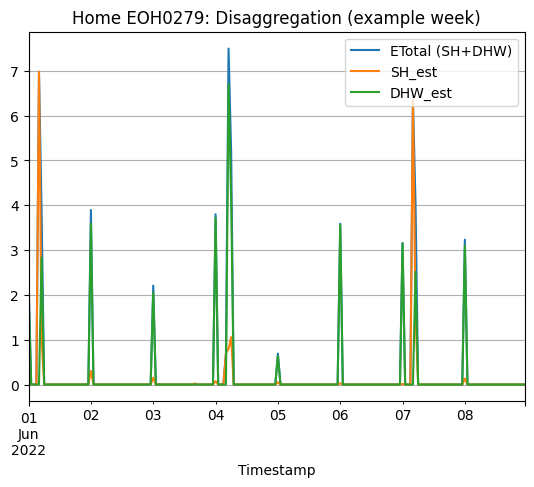

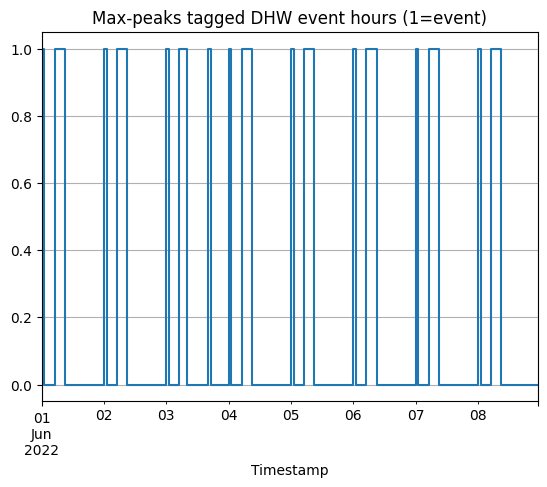

In [79]:
import matplotlib.pyplot as plt

# --- pick home ---
df_single_half = (df_train_detached_half_hour[df_train_detached_half_hour
                                             ["Property_ID"] == id_use].copy())
df_single_half["Timestamp"] = pd.to_datetime(df_single_half["Timestamp"])
df_single_half = df_single_half.set_index("Timestamp").sort_index()

# Your diff (make sure it is energy-per-step; if it’s cumulative, diff is right)
df_single_half["ETotal_step"] = df_single_half["Heat_Pump_Energy_Output"].diff()

# ---- resample to hourly ETotal (kWh/h) ----
# If original is half-hourly energy (kWh/0.5h), summing over 1h gives kWh/h over that hour.
df_hourly = pd.DataFrame(index=df_single_half.resample("1H").sum().index)
df_hourly["ETotal_kWh_h"] = df_single_half["ETotal_step"].resample("1H").sum()

# Weather inputs (hourly mean is fine)
df_hourly["External_Air_Temperature"] = df_single_half["External_Air_Temperature"].resample("1H").mean()
df_hourly["Global_Horizontal_Irradiance"] = (df_single_half["SolarRadiation"].resample("1H")
                                             .mean())

# Drop junk hours
df_hourly = df_hourly.replace([np.inf, -np.inf], np.nan).dropna()
df_hourly_year = df_hourly[(df_hourly.index >= t_start) & (df_hourly.index <= t_end)]

if df_home_single["Occupancy"].iloc[0] <= 2:
    top_n = 5
else: 
    top_n = 7
# ---- run Leiria best method ----
df_out = leiria_dhw_disaggregate(
    df_hourly_year,
    col_etotal="ETotal_kWh_h",
    col_tout="External_Air_Temperature",
    col_rad="Global_Horizontal_Irradiance",
    top_n=top_n,
    gap_hours_kalman=2
)

# ---- annual DHW estimate ----
dhw_annual_kwh = df_out["DHW_est_kWh_h"].sum()

# Provided “estimated annual DHW” for this home
mcs_dhw_annual_kwh = float(df_house.loc[df_house["Property_ID"] == id_use, "MCS_DHWAnnual"].iloc[0])

err_abs = dhw_annual_kwh - mcs_dhw_annual_kwh
err_pct = 100.0 * err_abs / mcs_dhw_annual_kwh
error_exact_abs_mcs = mcs_dhw_annual_kwh - q_dhw_exact
error_exact_pct_mcs = 100 * error_exact_abs_mcs / q_dhw_exact
error_exact_abs_leiria = dhw_annual_kwh - q_dhw_exact
error_exact_pct_leiria = 100 * error_exact_abs_leiria / q_dhw_exact



print(f"Home {id_use}")
print(f"Leiria-estimated DHW annual: {dhw_annual_kwh:,.1f} kWh")
print(f"MCS_DHWAnnual (provided):    {mcs_dhw_annual_kwh:,.1f} kWh")
print(f"From data (hot_water_flow_temp):    {q_dhw_exact:,.1f} kWh")
print(f"Error between MCS and Leiria: {err_abs:,.1f} kWh  ({err_pct:+.1f}%)")
print(f"Error between MCS and real: {error_exact_abs_mcs:,.1f} kWh  "
      f"({error_exact_pct_mcs:+.1f}%)")
print(f"Error between leiria and real: {error_exact_abs_leiria:,.1f} kWh  "
      f"({error_exact_pct_leiria:+.1f}%)")

# ---- quick visual sanity checks ----
week = df_out.loc["2022-06-01":"2022-06-08"]  # pick any window you like

plt.figure()
week["ETotal_kWh_h"].plot(label="ETotal (SH+DHW)")
week["SH_est_kWh_h"].plot(label="SH_est")
week["DHW_est_kWh_h"].plot(label="DHW_est")
plt.legend(); plt.grid(True); plt.title(f"Home {id_use}: Disaggregation (example week)")
plt.show()

plt.figure()
week["DHW_event_hour"].plot(label="DHW_event_hour", drawstyle="steps-post")
plt.grid(True); plt.title("Max-peaks tagged DHW event hours (1=event)"); plt.show()
